In [24]:
import numpy as np
import time
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from networks import regular_lattice, influencer_network
import matrix_utils as mu
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


done


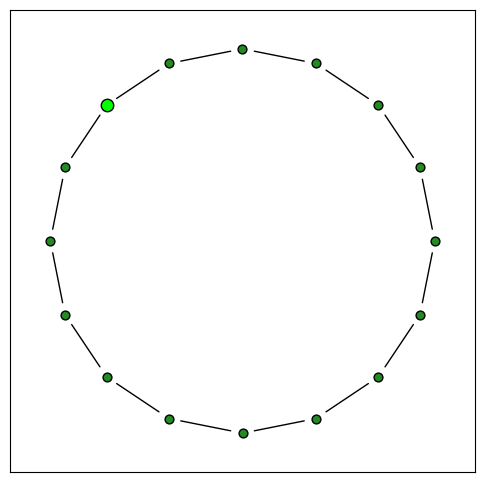

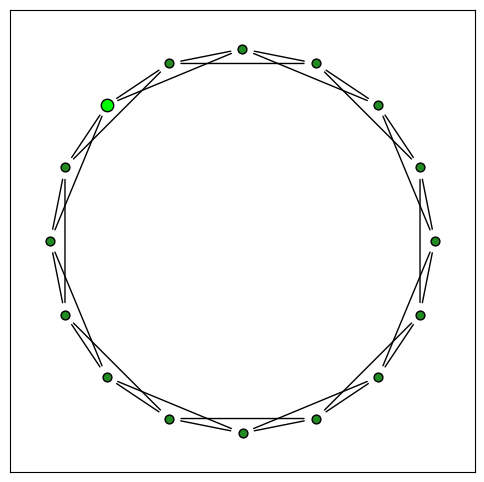

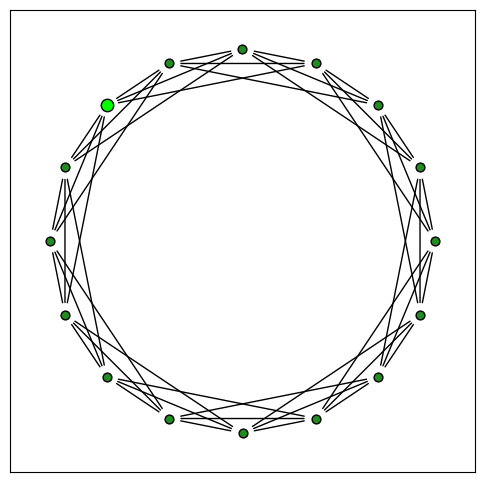

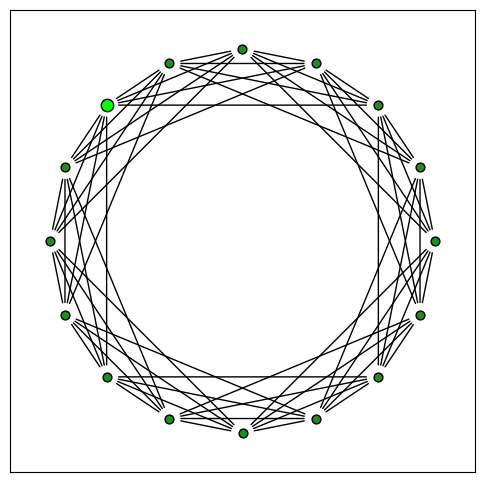

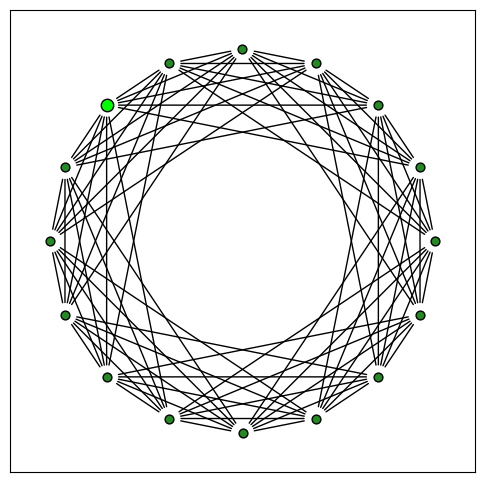

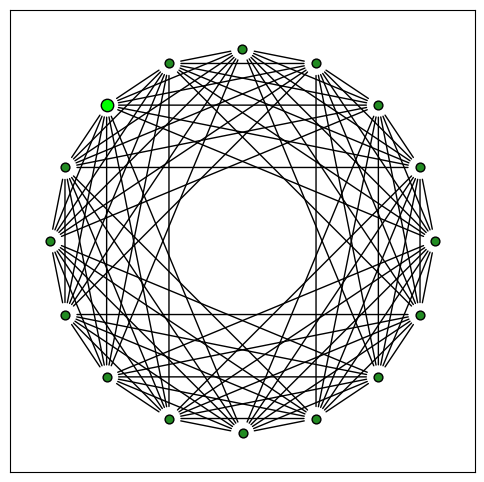

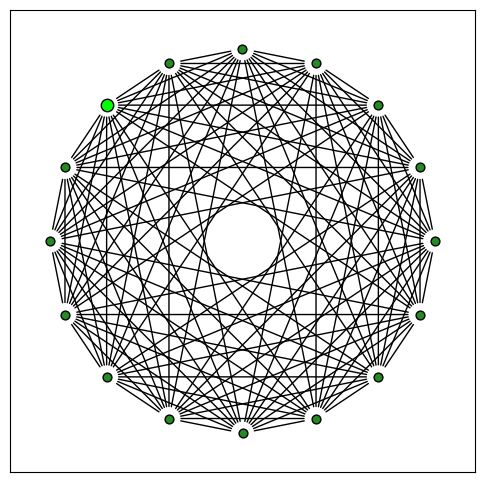

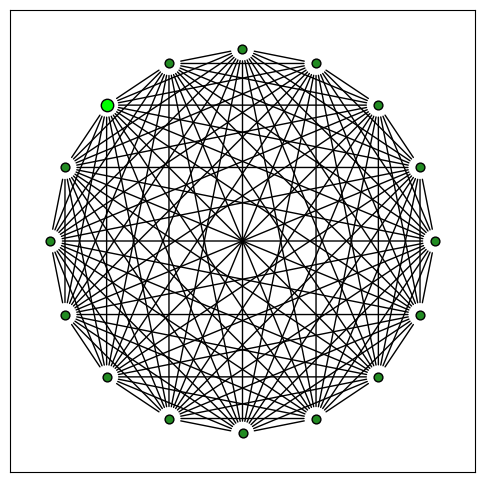

In [39]:
# Create graph from adjacency matrix

def run(n, save=False):
    def draw(A, highlight=[]):
        #clear_output(wait=True)
        G = nx.from_numpy_array(A, create_using=nx.Graph)
        pos = nx.circular_layout(G)
        plt.figure(figsize=(6, 6))

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[i for i in range(n) if i not in highlight],
            #arrowstyle='-|>',
            node_color="forestgreen",
            node_size=40,
            edgecolors="black",
        )
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=highlight,
            #arrowstyle='-|>',
            node_color="lime",
            node_size=2*40,
            edgecolors="black",
        )
        nx.draw_networkx_edges(
            G,
            pos,
            arrows=True,
            edgelist=list(G.edges()),
            arrowstyle=None,
            edge_color="black",
            arrowsize=0
        )
        plt.axis("equal")
        if not save:
            plt.show()
        else:
            plt.savefig(

    f"pngs/plot{degree}.png",
    format="png",
    transparent=True,
    bbox_inches="tight"

)
    degree = 2
    while(True):
        A = regular_lattice(n, degree)
        conn = mu.algebraic_connectivity(A)
        draw(A, highlight=[6])
        
        if not save:
            time.sleep(1)
        if np.isclose(conn, n):
            break
        degree += 2
    print("done")
    
run(16,save=True)

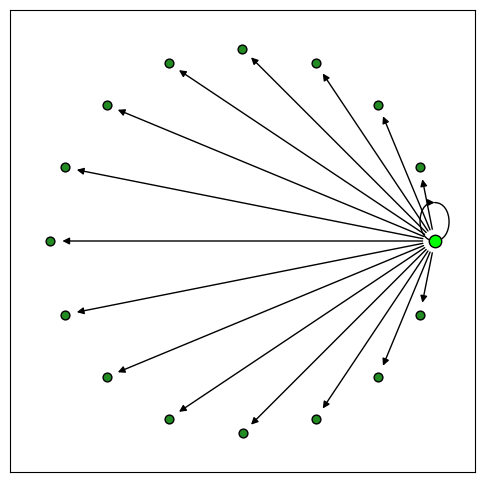

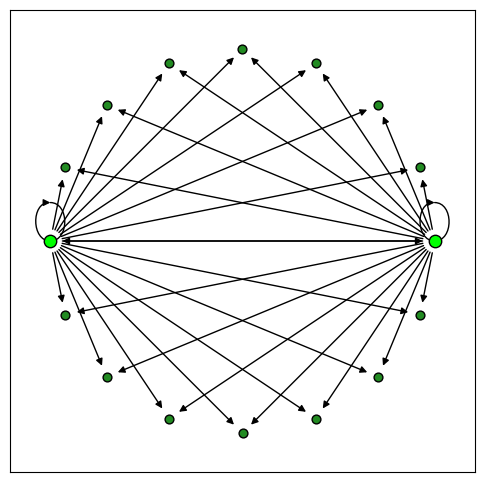

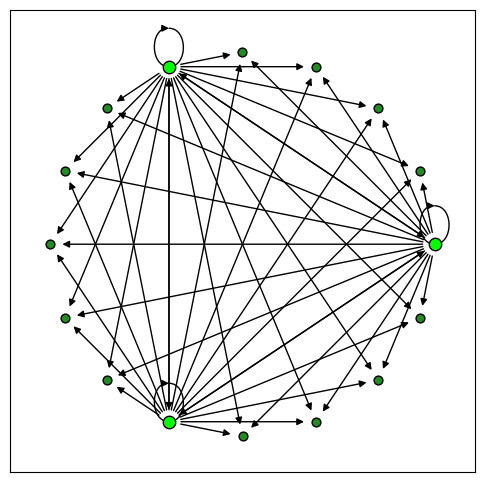

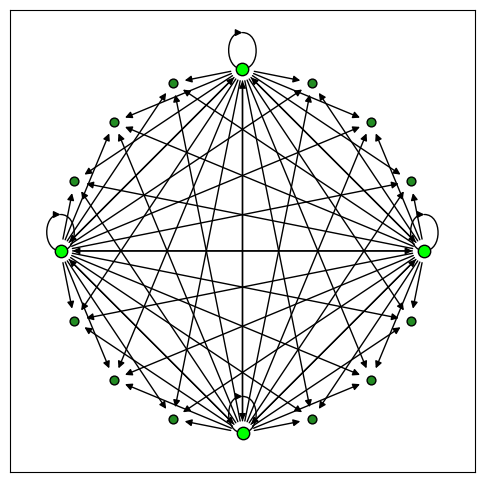

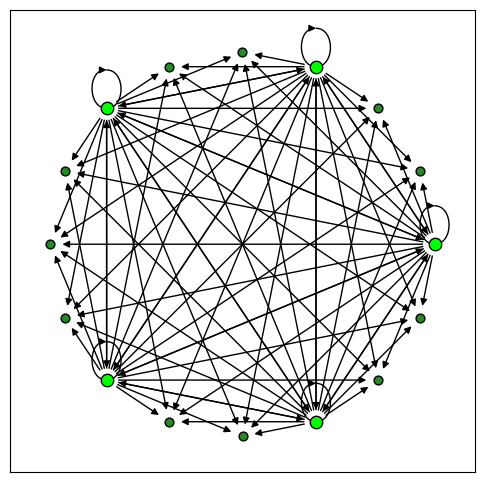

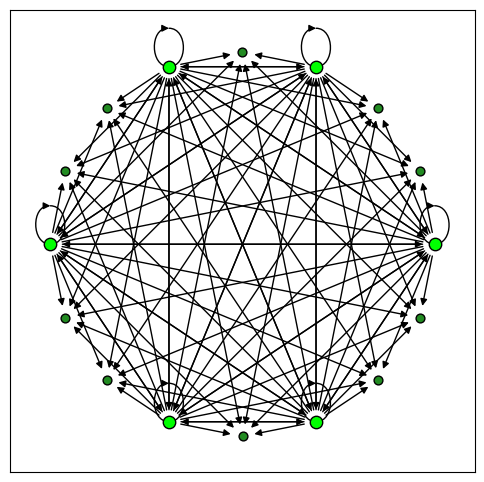

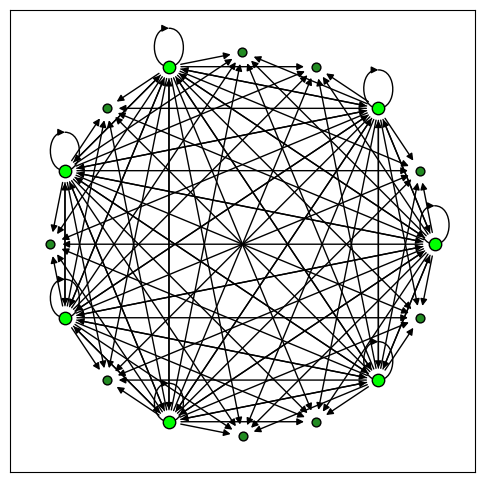

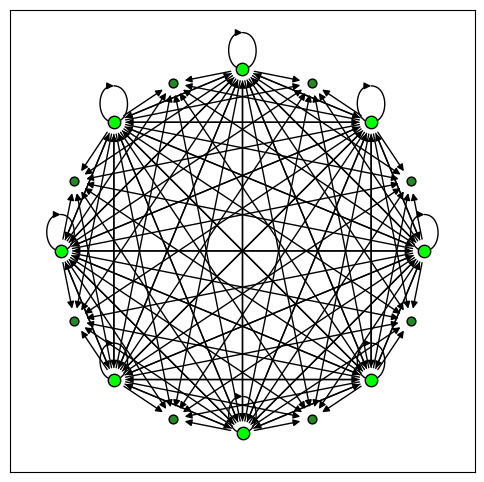

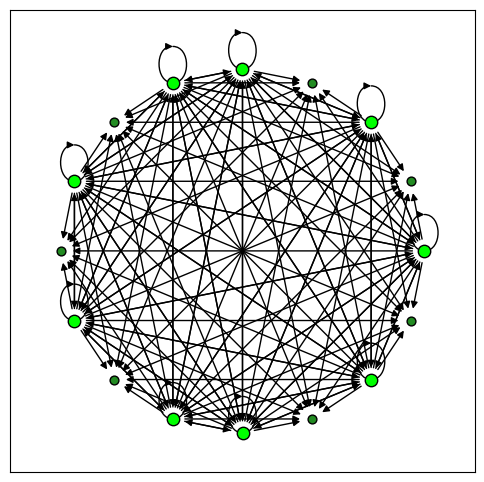

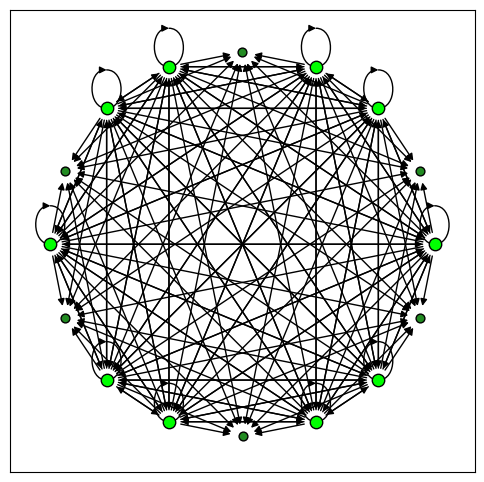

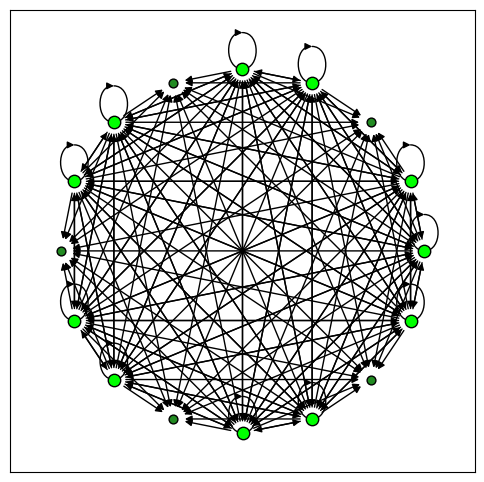

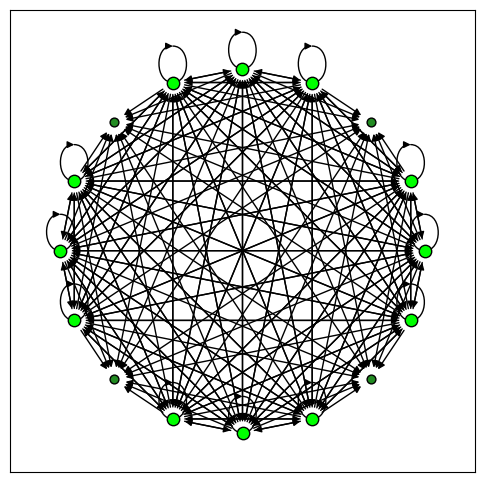

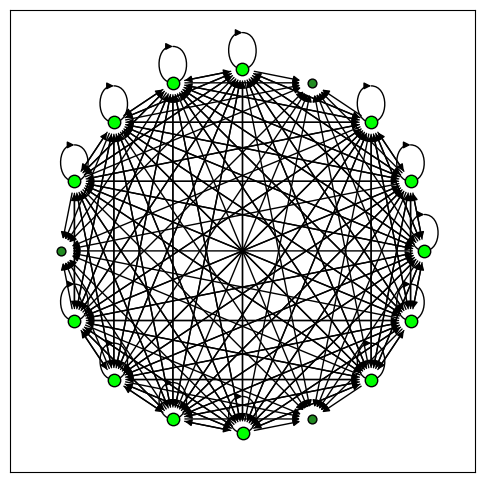

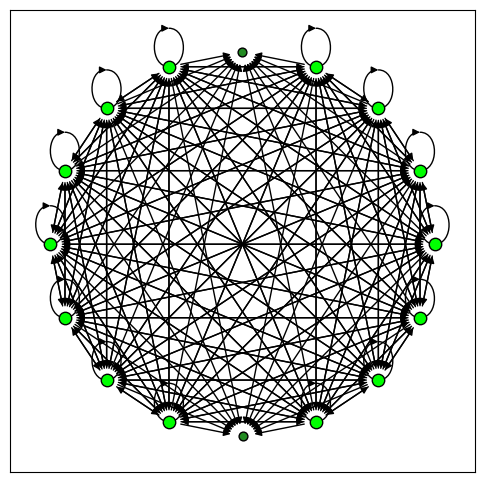

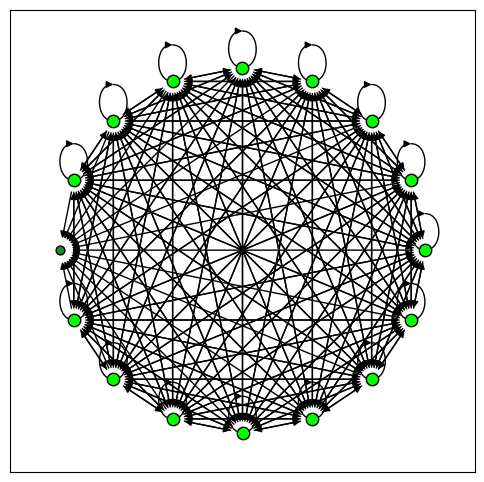

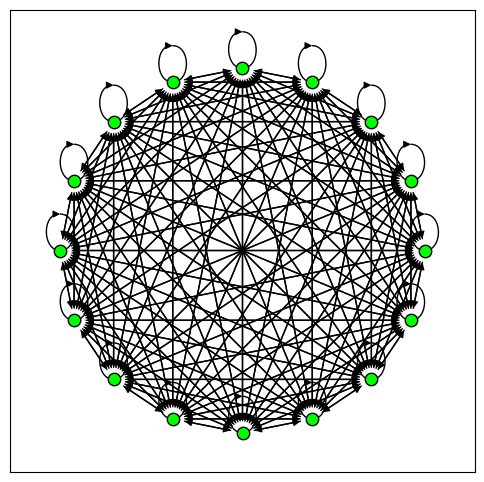

done


In [37]:
# Create graph from adjacency matrix

def run(n, save=False):
    def draw(A, highlight=[]):
        #clear_output(wait=True)
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)
        pos = nx.circular_layout(G)
        plt.figure(figsize=(6, 6))

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[i for i in range(n) if i not in highlight],
            #arrowstyle='-|>',
            node_color="forestgreen",
            node_size=40,
            edgecolors="black",
        )
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=highlight,
            #arrowstyle='-|>',
            node_color="lime",
            node_size=2*40,
            edgecolors="black",
        )
        nx.draw_networkx_edges(
            G,
            pos,
            arrows=True,
            edgelist=list(G.edges()),
            arrowstyle='-|>',
            edge_color="black",
            arrowsize=10
        )
        plt.axis("equal")
        if not save:
            plt.show()
        else:
            plt.savefig(

    f"pngs/plot{degree}.png",
    format="png",
    transparent=True,
    bbox_inches="tight"

)
    start = 0
    n_influencers = 1
    while(True):
        influencers = influencers = np.round(np.linspace(start, n+start, n_influencers, endpoint=False))
        influencers = [int(i) % n for i in influencers]
        A = influencer_network(n, influencers)
        draw(A.T, highlight=influencers)
        
        if not save:
            time.sleep(1)
        if n_influencers >= n:
            break
        n_influencers += 1
    print("done")
    
run(16)